<a href="https://colab.research.google.com/github/Franzzz-kun/Python-for-Chemical-Engineering-Projects-and-Automations/blob/branch_1/Common_Cubic_Equation_of_State_in_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Common Cubic Equation of State in Python**

This python code computes different types of **equations of state** through the use of python. The common equations of state (EoS) includes the following:
*   Van der Waals
*   Redlich-Kwong
*   Soave
*   Peng-Robinson

The general equation for ideal law is stated below:

$ z = \frac{PV}{RT}$

Wherein z is the compressibility factor, P is the pressure, V is the volume, RT is the gas constant, T is the temperature. Moreover, the general Cubic Equation of State (EoS) is stated below:

$z = \frac{V}{V - b} - \frac{V [a α(T_r)]}{(V^2 + δV + ε) RT}$



!Insert the following Data!
Insert compound name: Water
Insert compound temperature in K: 353.15
Insert compound molar volume in cm³/mol: 1000000
Insert compound critical temperature in K: 647.096
Insert compound critical pressure in bar: 220.64
Insert compound accentric factor: 0.344861

!The pressures at different cubic Equations of State!
The pressure at ideal is 0.029362657 bar.
The pressure at Van der Waal is 0.029358017 bar.
The pressure at Redlich-Kwong is 0.029355685 bar.
The pressure at Soave is 0.029354349 bar.
The pressure at Peng-Robinson is 0.029354161 bar.

!Graph of the Pressure vs. Temperature!



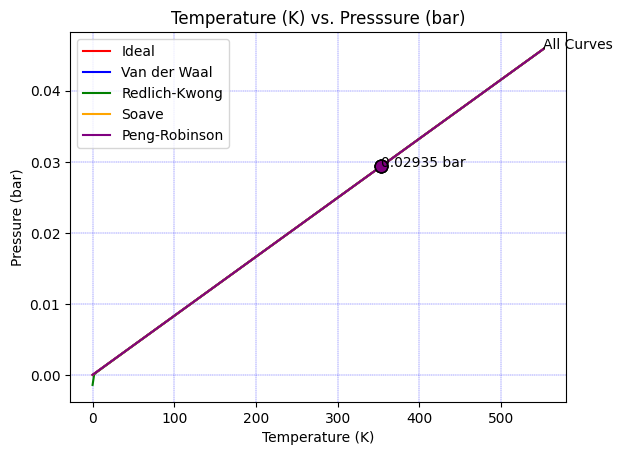

In [ ]:
# with Van der Waal Equation

import numpy as np
import math
import matplotlib.pyplot as plt

# Global Variables
gas_constant = 83.145 # bar-cm³/mol-K

def ideal_gas(ideal_gas_temp, ideal_gas_vol):
  """This is for the ideal gas law."""
  z = 1
  ideal_gas_const = 83.145 # bar-cm³/mol-K
  Pressure = float( (z * ideal_gas_const * ideal_gas_temp) / ideal_gas_vol)
  return Pressure # bar

def EOS_Van_der_Waals(EOS_temp, EOS_pressure, temp, vol):
    """This is for the Van der Waal Equation."""
    a = round((0.42188 * ( gas_constant * EOS_temp ) ** 2) / EOS_pressure, 5)
    b = round(( 0.125 * gas_constant * EOS_temp ) / EOS_pressure, 5)
    z_value = vol / ( vol - b ) - ( vol * a * 1 ) / ((vol**2 + 0 * vol + 0) * gas_constant * temp)
    pressure_VDW = z_value * gas_constant * temp / vol
    return pressure_VDW # bar

def EOS_Redlich_Kwong(EOS_temp, EOS_pressure, temp, vol):
    """This is for the Redlich-Kwong Equation."""
    a = round((0.42748 * ( gas_constant * EOS_temp ) ** 2) / EOS_pressure, 5)
    b = round(( 0.08664 * gas_constant * EOS_temp ) / EOS_pressure, 5)
    z_value = vol / ( vol - b ) - ( vol * a * (1 /math.sqrt( temp / EOS_temp )) ) / ((vol**2 + b * vol + 0) * gas_constant * temp)
    pressure_RK = z_value * gas_constant * temp / vol
    return pressure_RK # bar

def EOS_Soave(EOS_temp, EOS_pressure, temp, vol, w):
    """This is for the Soave Equation."""
    a = round((0.42748 * ( gas_constant * EOS_temp ) ** 2) / EOS_pressure, 5)
    b = round(( 0.08664 * gas_constant * EOS_temp ) / EOS_pressure, 5)
    Tr = (1 + (0.48 + 1.574 * w - 0.176 * w ** 2) * (1 - math.sqrt(temp / EOS_temp) ) ) ** 2
    z_value = vol / ( vol - b ) - ( vol * a * Tr ) / ((vol**2 + b * vol + 0) * gas_constant * temp)
    pressure_Soave = z_value * gas_constant * temp / vol
    return pressure_Soave # bar

def EOS_Peng_Robinson(EOS_temp, EOS_pressure, temp, vol, w):
    """This is for the Peng-Robinson Equation."""
    a = round((0.45724 * ( gas_constant * EOS_temp ) ** 2) / EOS_pressure, 5)
    b = round(( 0.0778 * gas_constant * EOS_temp ) / EOS_pressure, 5)
    Tr = (1 + (0.37464 + 1.54226 * w - 0.2699 * w ** 2) * (1 - math.sqrt(temp / EOS_temp) ) ) ** 2
    z_value = vol / ( vol - b ) - ( vol * a * Tr ) / ((vol**2 + b * vol + 0) * gas_constant * temp)
    pressure_PR = z_value * gas_constant * temp / vol
    return pressure_PR # bar

print("!Insert the following Data!")
comp_name = str(input("Insert compound name: "))
given_temp = float(input("Insert compound temperature in K: "))
given_vol = float(input("Insert compound molar volume in cm³/mol: "))
critical_temp = float(input("Insert compound critical temperature in K: "))
critical_pressure = float(input("Insert compound critical pressure in bar: "))
accentric_factor = float(input("Insert compound accentric factor: "))
final_ideal = ideal_gas(given_temp, given_vol)
final_VDW = EOS_Van_der_Waals(critical_temp, critical_pressure, given_temp, given_vol)
final_RK = EOS_Redlich_Kwong(critical_temp, critical_pressure, given_temp, given_vol)
final_Soave = EOS_Soave(critical_temp, critical_pressure, given_temp, given_vol, accentric_factor)
final_PR = EOS_Peng_Robinson(critical_temp, critical_pressure, given_temp, given_vol, accentric_factor)

print()
print("!The pressures at different cubic Equations of State!")
print(f"The pressure at ideal is {final_ideal:.9f} bar.")
print(f"The pressure at Van der Waal is {final_VDW:.9f} bar.")
print(f"The pressure at Redlich-Kwong is {final_RK:.9f} bar.")
print(f"The pressure at Soave is {final_Soave:.9f} bar.")
print(f"The pressure at Peng-Robinson is {final_PR:.9f} bar.")

print()
print("!Graph of the Pressure vs. Temperature!")
print()

# For Plot Number 1 (Zero is the basis or base point)
my_temp = [] # temperature at K
my_press_ideal = [] # bar and it varies depending on the type of cubic Equations of State
my_press_VDW = []
my_press_RK = []
my_press_Soave = []
my_press_PR = []

for i in range(0, round(given_temp + 200), 2):
  my_temp.append(i)
  if i == 0:
    my_temp[0] = 0.01

for j in my_temp:
  final_value_ideal = ideal_gas(j, given_vol)
  final_value_VDW = EOS_Van_der_Waals(critical_temp, critical_pressure, j, given_vol)
  final_value_RK = EOS_Redlich_Kwong(critical_temp, critical_pressure, j, given_vol)
  final_value_Soave = EOS_Soave(critical_temp, critical_pressure, j, given_vol, accentric_factor)
  final_value_PR = EOS_Peng_Robinson(critical_temp, critical_pressure, j, given_vol, accentric_factor)
  my_press_ideal.append(final_value_ideal)
  my_press_VDW.append(final_value_VDW)
  my_press_RK.append(final_value_RK)
  my_press_Soave.append(final_value_Soave)
  my_press_PR.append(final_value_PR)

'''
print(my_temp)
print(my_press_ideal)
print(my_press_VDW)
print(my_press_RK)
print(my_press_Soave)
print(my_press_PR)
'''

plt.plot(my_temp, my_press_ideal, color = 'red', label="Ideal")
plt.plot(my_temp, my_press_VDW, color = 'blue', label ="Van der Waal")
plt.plot(my_temp, my_press_RK, color = 'green', label ="Redlich-Kwong")
plt.plot(my_temp, my_press_Soave, color = 'orange', label ="Soave")
plt.plot(my_temp, my_press_PR, color = 'purple', label="Peng-Robinson")

plt.plot(given_temp, final_ideal, color = 'red', marker = 'o', markersize = 9, markeredgecolor="black", markeredgewidth = 1)
plt.plot(given_temp, final_VDW, color = 'blue', marker = 'o', markersize = 9, markeredgecolor="black", markeredgewidth = 1)
plt.plot(given_temp, final_RK, color = 'green', marker = 'o', markersize = 9, markeredgecolor="black", markeredgewidth = 1)
plt.plot(given_temp, final_Soave, color = 'orange', marker = 'o', markersize = 9, markeredgecolor="black", markeredgewidth = 1)
plt.plot(given_temp, final_PR, color = 'purple', marker = 'o', markersize = 9, markeredgecolor="black", markeredgewidth = 1)

plt.title("Temperature (K) vs. Presssure (bar)")
plt.xlabel("Temperature (K)")
plt.ylabel("Pressure (bar)")

# For the PR
plt.text(my_temp[-1], my_press_PR[-1], f'All Curves')
plt.text(given_temp, final_PR, f'{final_PR:.5f} bar')

plt.grid(color = 'b', linestyle = '--', linewidth = 0.25)
plt.legend()
plt.show()



In [ ]:
# Suggestions
# 1. Use np.linspace for the temperature.